In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA

In [7]:
df1 = pd.read_csv("s214696_1.csv")
df2 = pd.read_csv("s214696_2.csv")
df3 = pd.read_csv("s224184_1.csv")
df4 = pd.read_csv("s224184_2.csv")
df5 = pd.read_csv("s224223_1.csv")
df6 = pd.read_csv("s224223_2.csv")


df = df1.merge(df2, on="filename", suffixes=("_1", "_2"))
df = df.merge(df3, on="filename")
df = df.merge(df4, on="filename", suffixes=("_3", "_4"))
df = df.merge(df5, on="filename")
df = df.merge(df6, on="filename", suffixes=("_5", "_6"))
print(df.head())

                                filename  rating_1  rating_2  rating_3  \
0  86_0_0_20170111222700442.jpg.chip.jpg         1         1         1   
1  70_1_1_20170110153248874.jpg.chip.jpg         4         5         5   
2  75_0_1_20170111210115928.jpg.chip.jpg         2         2         1   
3  89_0_2_20170112220351776.jpg.chip.jpg         1         1         2   
4  89_1_3_20170110182042731.jpg.chip.jpg         4         4         5   

   rating_4  rating_5  rating_6  
0         1         1         1  
1         5         5         5  
2         1         1         1  
3         1         1         1  
4         5         5         4  


In [12]:
cols = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df["avg"] = df[cols].mean(axis=1)

In [13]:
df["age"]    = df["filename"].str.split("_").str[0].astype(int)
df["gender"] = df["filename"].str.split("_").str[1].astype(int)

print(df["gender"].value_counts())
print(df["gender"].value_counts(normalize=True).round(3))

gender
0    117
1    117
Name: count, dtype: int64
gender
0    0.5
1    0.5
Name: proportion, dtype: float64


In [14]:
n = df["gender"].value_counts().min()

df = (df.groupby("gender", group_keys=False)
        .sample(n=n, random_state=0)
        .reset_index(drop=True))

print(df["gender"].value_counts())

gender
0    117
1    117
Name: count, dtype: int64


          rating_1  rating_2  rating_3  rating_4  rating_5  rating_6
rating_1     1.000     0.942     0.935     0.921     0.920     0.914
rating_2     0.942     1.000     0.939     0.923     0.918     0.918
rating_3     0.935     0.939     1.000     0.964     0.938     0.922
rating_4     0.921     0.923     0.964     1.000     0.921     0.919
rating_5     0.920     0.918     0.938     0.921     1.000     0.970
rating_6     0.914     0.918     0.922     0.919     0.970     1.000


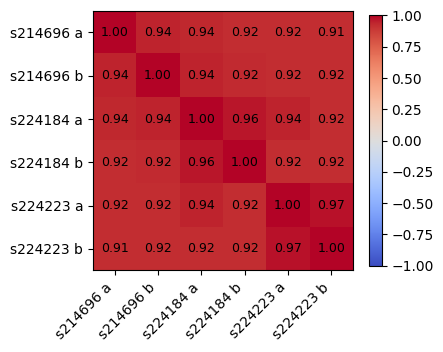

In [16]:
cols = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6"]
corr = df[cols].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

labels = ["s214696 a", "s214696 b", "s224184 a", "s224184 b", "s224223 a", "s224223 b"]
ax.set_xticks(range(6), labels, rotation=45, ha="right")
ax.set_yticks(range(6), labels)

for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

In [59]:
cols = ["rating_1", "rating_2", "rating_3", "rating_4"]
corr = np.corrcoef(df[cols].values, rowvar=False)
mean_r = corr[np.triu_indices_from(corr, k=1)].mean()
print(round(mean_r, 3))

0.937


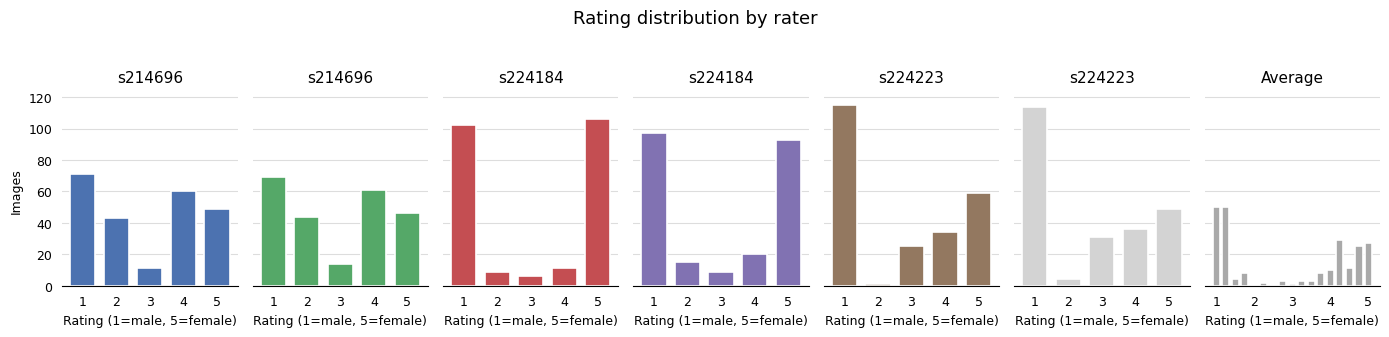

In [17]:

cols   = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6", "avg"]
titles = ["s214696", "s214696", "s224184", "s224184", "s224223", "s224223", "Average"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860", "#D3D3D3", "#A9A9A9"]

int_bins = np.arange(0.5, 6.5, 1)          # one bar per whole rating
avg_bins = np.arange(0.875, 5.26, 0.25)    # quarter steps for the mean

fig, axes = plt.subplots(1, 7, figsize=(14, 3.2), sharey=True)

for ax, col, title, c in zip(axes, cols, titles, colors):
    bins = avg_bins if col == "avg" else int_bins
    ax.hist(df[col].dropna(), bins=bins, rwidth=0.75,
            color=c, edgecolor="white", linewidth=1.2)

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("Rating (1=male, 5=female)", fontsize=9)

    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelsize=9)

axes[0].set_ylabel("Images", fontsize=9)
fig.suptitle("Rating distribution by rater", fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("histogram.png")

In [24]:

folder = Path("70+_clean")
gray_folder = Path("/Users/andreaseefsen/Desktop/02458/Cognitive_mod/70+_gray")
gray_folder.mkdir(exist_ok=True)

SIZE = (200, 200)

filenames = df["filename"].tolist()
X = np.stack([
    np.asarray(
        Image.open(folder / f).convert("L").save(gray_folder / f)
        or Image.open(gray_folder / f), dtype=np.float64
    ).ravel()
    for f in filenames
])

print(X.shape)


def load(f):
    with Image.open(gray_folder / f) as img:
        return np.asarray(img, dtype=np.float64).ravel()

X = np.stack([load(f) for f in df["filename"]])
print(X.shape)

(234, 40000)
(234, 40000)


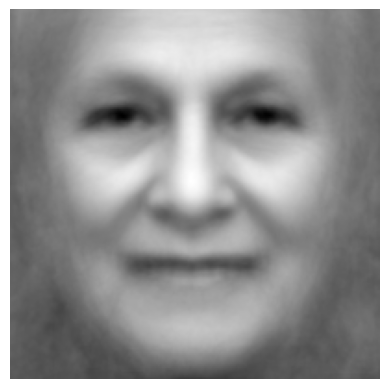

In [26]:
import matplotlib.pyplot as plt

SIZE = (200, 200)
mean_img = X.mean(axis=0)

plt.imshow(mean_img.reshape(SIZE), cmap="gray")
plt.axis("off")
plt.show()

In [27]:
Xc = X - mean_img
pca = PCA()
Z = pca.fit_transform(Xc)
print(Z.shape)

(234, 234)


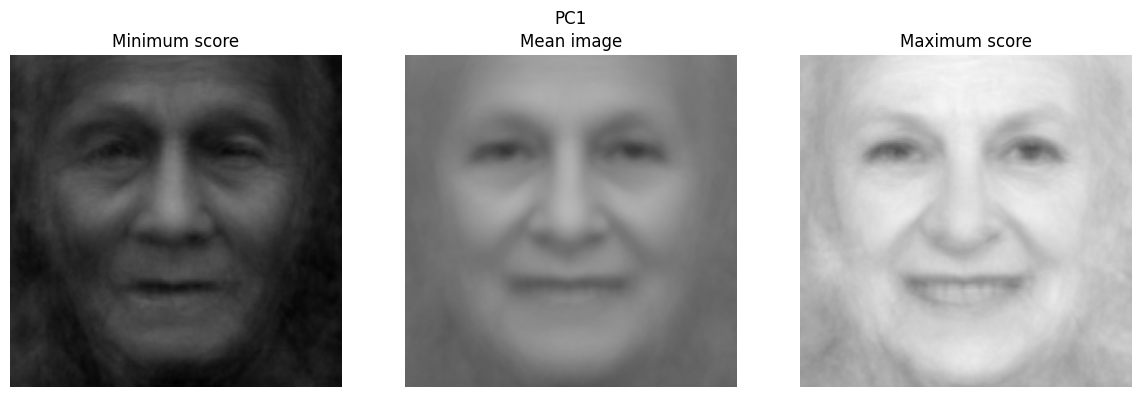

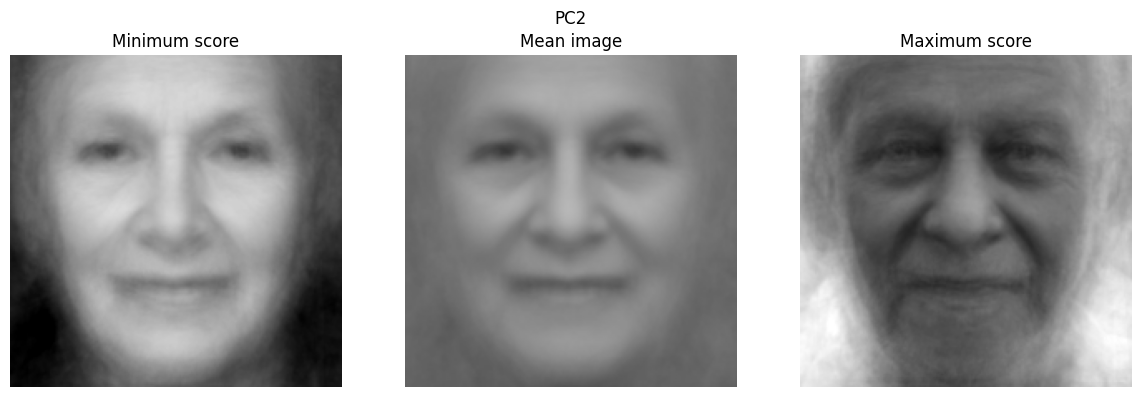

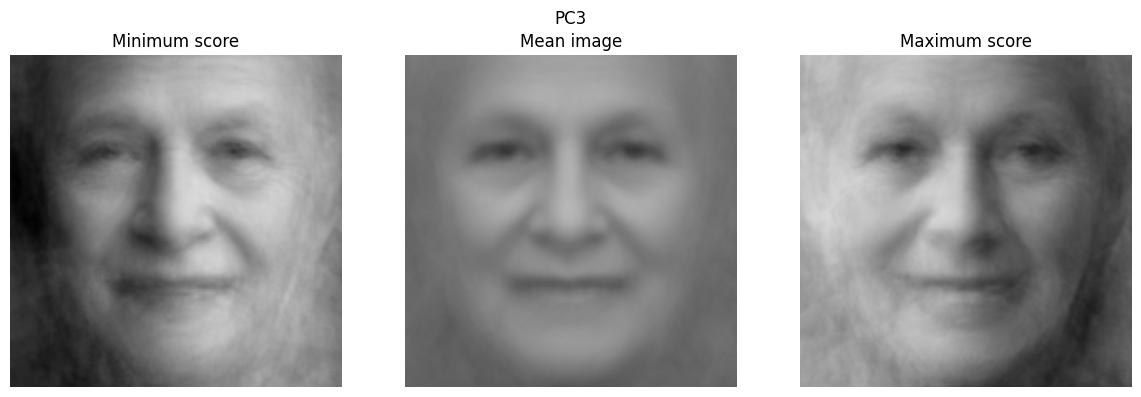

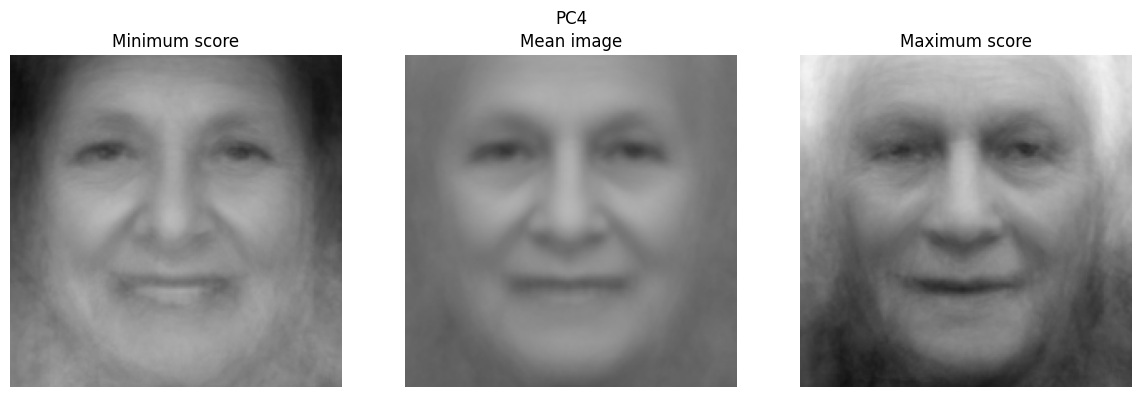

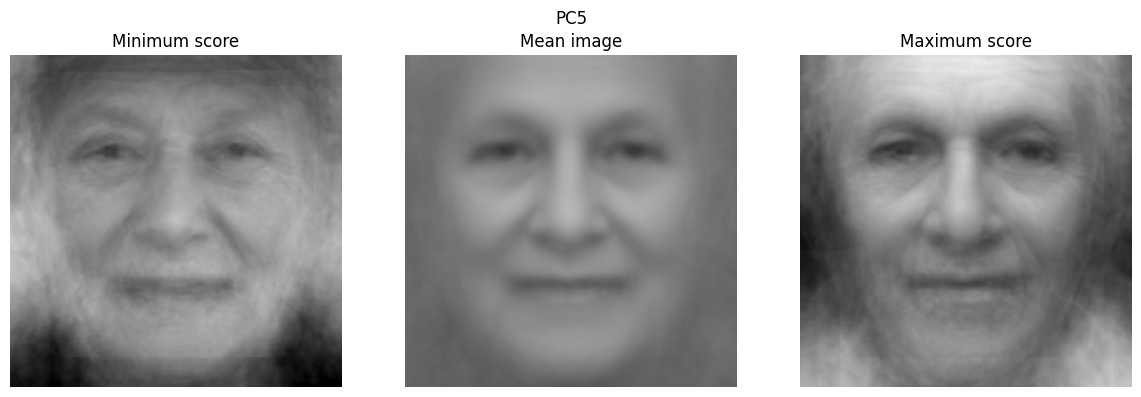

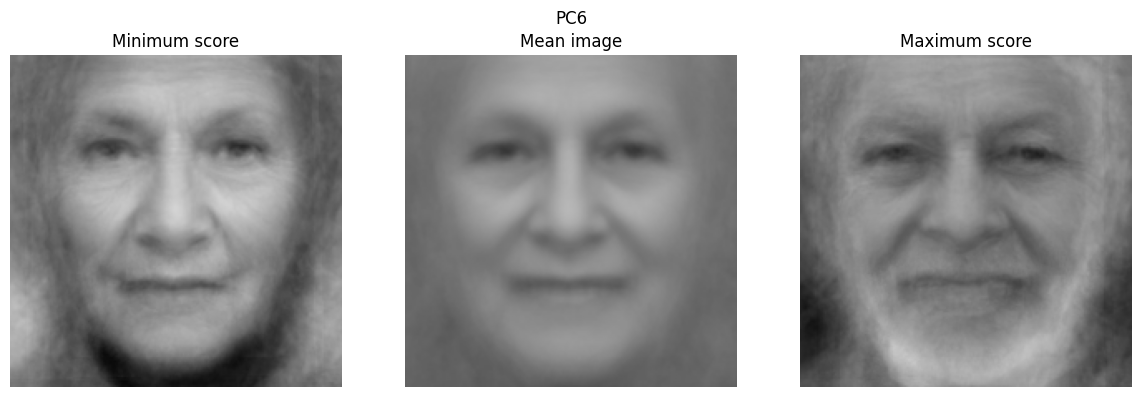

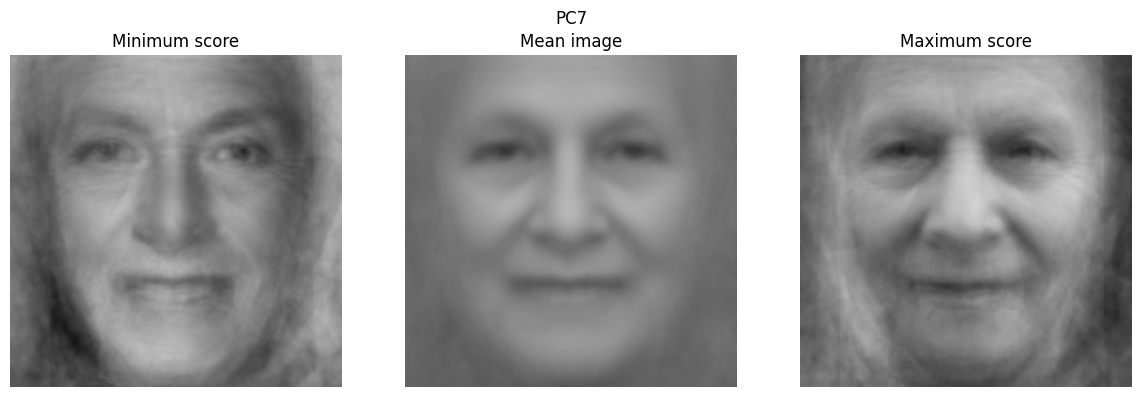

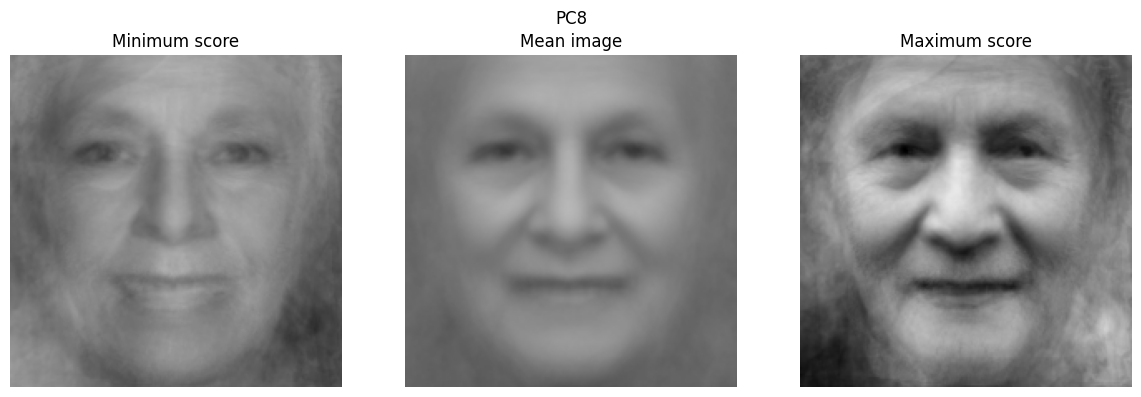

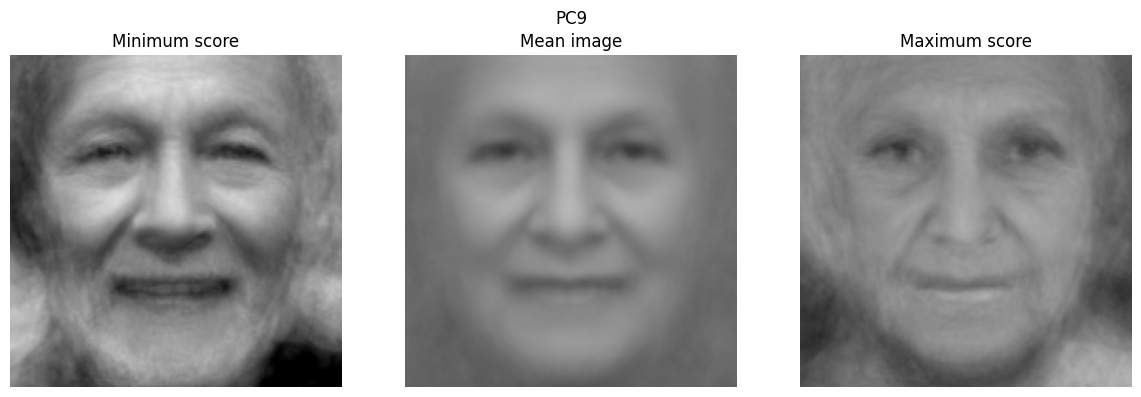

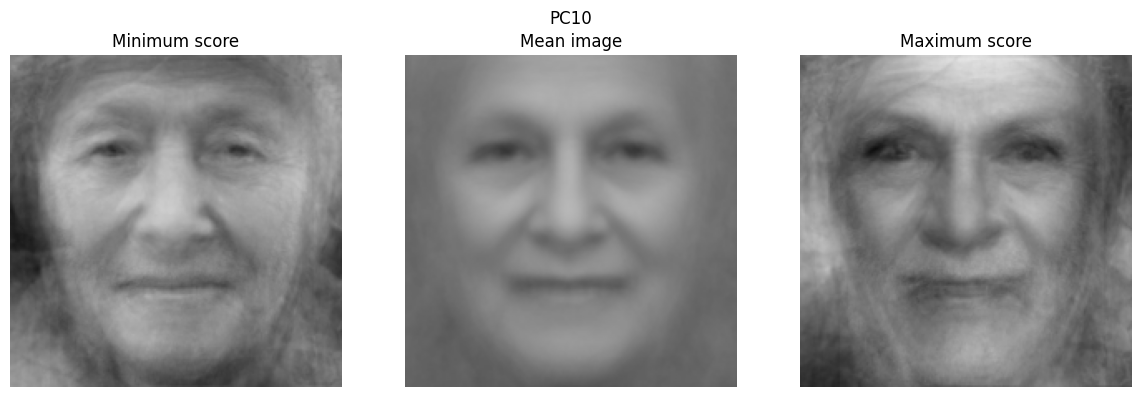

In [28]:
for nr in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    pc = pca.components_[nr]
    scores = Z[:, nr]

    img_min  = mean_img + scores.min() * pc
    img_mean = mean_img
    img_max  = mean_img + scores.max() * pc

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_min.reshape(SIZE),  cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Minimum score")

    axes[1].imshow(img_mean.reshape(SIZE), cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Mean image")

    axes[2].imshow(img_max.reshape(SIZE),  cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Maximum score")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(f"PC{nr + 1}")
    plt.tight_layout()
    plt.show()

In [29]:
# Order all PCs by how strongly they correlate with our ratings, strongest first.
# This is just a check - forward selection does the real picking later.
# We use it to see how far down the list the useful components go, so we know how many to keep as candidates (elbow).
variance = pca.explained_variance_ratio_

r = np.array([np.corrcoef(Z[:, k], df["avg"])[0, 1] for k in range(Z.shape[1])])

order = np.argsort(-np.abs(r))
for k in order[:20]:
    print(f"PC{k+1:>3}: r = {r[k]:+.3f}   (variance {variance[k]:.3%})")

PC  2: r = -0.290   (variance 12.793%)
PC 17: r = -0.233   (variance 0.742%)
PC 29: r = -0.223   (variance 0.419%)
PC 23: r = +0.221   (variance 0.523%)
PC  6: r = -0.214   (variance 2.460%)
PC  1: r = +0.199   (variance 26.429%)
PC 25: r = -0.174   (variance 0.486%)
PC  8: r = -0.169   (variance 1.921%)
PC 33: r = +0.150   (variance 0.374%)
PC 16: r = -0.148   (variance 0.829%)
PC 13: r = +0.143   (variance 1.002%)
PC 90: r = +0.135   (variance 0.104%)
PC115: r = +0.135   (variance 0.073%)
PC 26: r = +0.130   (variance 0.475%)
PC 15: r = +0.127   (variance 0.842%)
PC107: r = -0.127   (variance 0.081%)
PC 46: r = -0.125   (variance 0.239%)
PC 68: r = +0.125   (variance 0.149%)
PC 28: r = -0.123   (variance 0.434%)
PC152: r = -0.120   (variance 0.047%)


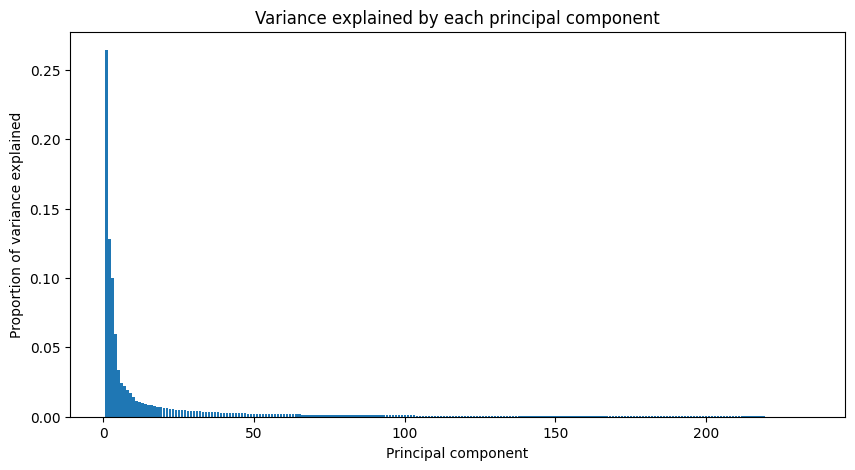

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(np.arange(1, len(variance) + 1), variance)

plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("Variance explained by each principal component")

plt.show()

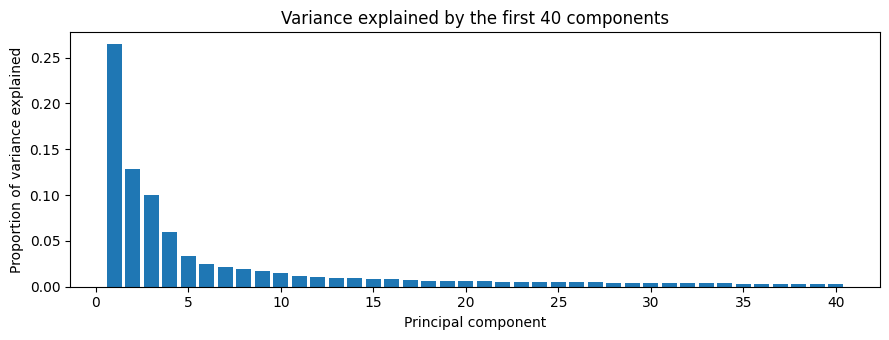

In [31]:
# Zoom in on the first 40 components to locate the elbow.
K_SHOW = 40

plt.figure(figsize=(9, 3.5))
plt.bar(np.arange(1, K_SHOW + 1), variance[:K_SHOW])
plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("Variance explained by the first 40 components")
plt.tight_layout()
plt.savefig("scree_zoom.png", dpi=150)
plt.show()

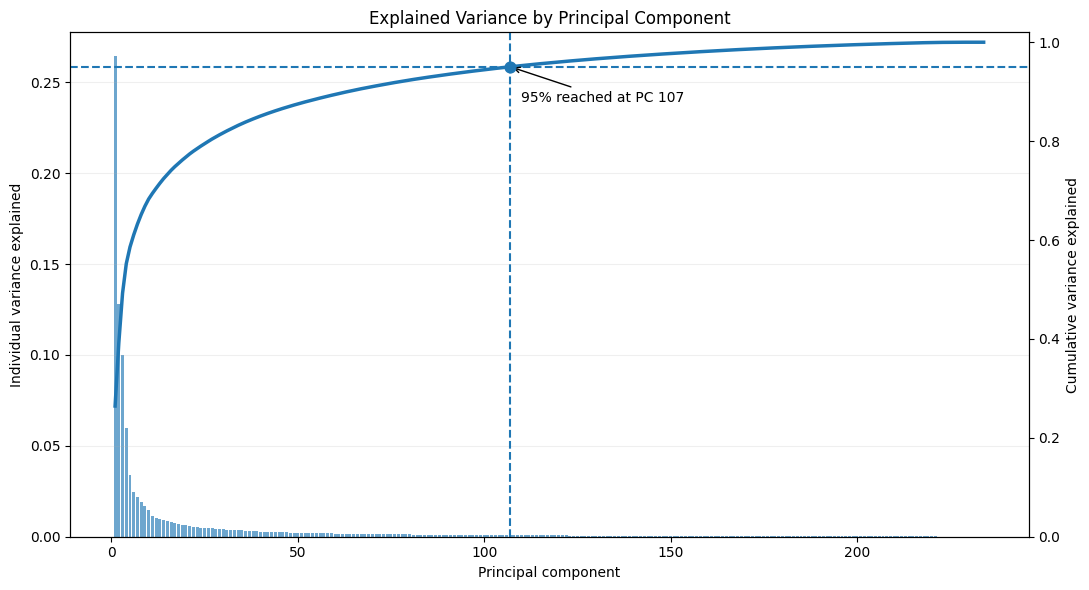

Number of PCs needed to explain at least 95% of the variance: 107


In [32]:
variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance)

pcs = np.arange(1, len(variance) + 1)

# First PC where cumulative explained variance reaches 95%
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

fig, ax1 = plt.subplots(figsize=(11, 6))

# Individual explained variance
ax1.bar(
    pcs,
    variance,
    alpha=0.65,
    label="Individual variance explained"
)

ax1.set_xlabel("Principal component")
ax1.set_ylabel("Individual variance explained")
ax1.grid(axis="y", alpha=0.2)

# Cumulative explained variance
ax2 = ax1.twinx()

ax2.plot(
    pcs,
    cumulative_variance,
    linewidth=2.5,
    label="Cumulative variance explained"
)

ax2.set_ylabel("Cumulative variance explained")
ax2.set_ylim(0, 1.02)

# 95% horizontal threshold
ax2.axhline(
    0.95,
    linestyle="--",
    linewidth=1.5
)

# Vertical line showing number of PCs needed
ax2.axvline(
    n_95,
    linestyle="--",
    linewidth=1.5
)

# Highlight the 95% point
ax2.scatter(
    n_95,
    cumulative_variance[n_95 - 1],
    s=60,
    zorder=5
)

ax2.annotate(
    f"95% reached at PC {n_95}",
    xy=(n_95, cumulative_variance[n_95 - 1]),
    xytext=(n_95 + 3, 0.88),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Explained Variance by Principal Component")

fig.tight_layout()
plt.show()

print(f"Number of PCs needed to explain at least 95% of the variance: {n_95}")

In [33]:
# Cut at the elbow in the scree plot.
# We keep 40 components as candidates for the forward selection—enough that we do not throw away components that matter for the ratings, but few enough to avoid overfitting with only 234 images.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

K = 40
Z_sel = Z[:, :K]
y = df["avg"].values

print(f"Keeping {K} components, explaining {variance[:K].sum():.1%} of the variance")
print("Z_sel:", Z_sel.shape)

Keeping 40 components, explaining 85.1% of the variance
Z_sel: (234, 40)


### Step 4: Forward Selection

Lowest CV error at 23 components
Order picked: ['PC2', 'PC6', 'PC29', 'PC23', 'PC17', 'PC1', 'PC8', 'PC16', 'PC13', 'PC33', 'PC25', 'PC28', 'PC26', 'PC15', 'PC9', 'PC14', 'PC4', 'PC3', 'PC22', 'PC31', 'PC11', 'PC12', 'PC37', 'PC30', 'PC27', 'PC35', 'PC39', 'PC19', 'PC18', 'PC10', 'PC36', 'PC40', 'PC21', 'PC24', 'PC5', 'PC32', 'PC7', 'PC38', 'PC34', 'PC20']


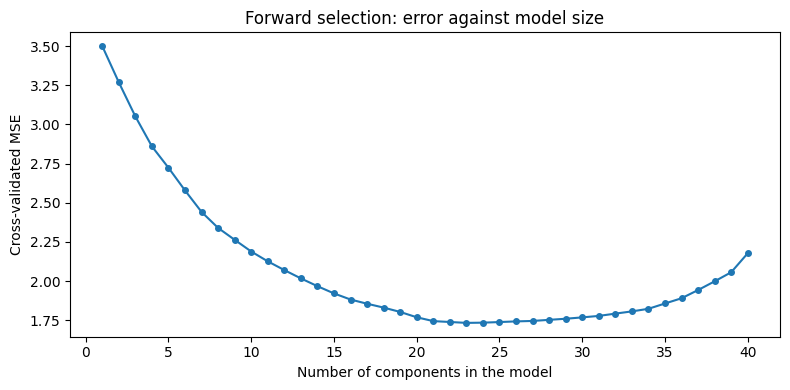

In [34]:
# Run forward selection: start with no components, then add the one that helps most, and repeat.
# Each candidate is judged with cross-validation, not on the training data, because more parameters always fit the training data better.
# We run all K=40 steps and plot the error so we can see where it stops improving.
selected_order, remaining, cv_errors = [], list(range(K)), []

for _ in range(K):
    best = min(remaining, key=lambda c: -cross_val_score(
        LinearRegression(), Z_sel[:, selected_order + [c]], y,
        cv=5, scoring="neg_mean_squared_error").mean())
    selected_order.append(best)
    remaining.remove(best)
    cv_errors.append(-cross_val_score(
        LinearRegression(), Z_sel[:, selected_order], y,
        cv=5, scoring="neg_mean_squared_error").mean())

cv_errors = np.array(cv_errors)
print(f"Lowest CV error at {cv_errors.argmin() + 1} components")
print("Order picked:", [f"PC{i+1}" for i in selected_order])

plt.figure(figsize=(8, 4))
plt.plot(range(1, K + 1), cv_errors, marker="o", markersize=4)
plt.xlabel("Number of components in the model")
plt.ylabel("Cross-validated MSE")
plt.title("Forward selection: error against model size")
plt.tight_layout()
plt.savefig("forward_selection.png", dpi=150)
plt.show()

In [35]:
# It looks like the curve is flat from about 20 components onwards. We take 20, where the curve levels off, since a smaller model is less likely to overfit with only 234 images.
n_final = 20
final_pcs = selected_order[:n_final]

print("Final components:", [f"PC{i+1}" for i in final_pcs])
print(f"CV error at {n_final}: {cv_errors[n_final-1]:.3f}  (best was {cv_errors.min():.3f})")

Final components: ['PC2', 'PC6', 'PC29', 'PC23', 'PC17', 'PC1', 'PC8', 'PC16', 'PC13', 'PC33', 'PC25', 'PC28', 'PC26', 'PC15', 'PC9', 'PC14', 'PC4', 'PC3', 'PC22', 'PC31']
CV error at 20: 1.769  (best was 1.733)


In [36]:
# Fit the final model on all 234 images using only the selected components.
# Cross-validation was used to choose the components; now we use everything to get the best estimate of the weights.
model = LinearRegression().fit(Z_sel[:, final_pcs], y)

w_pc = model.coef_ # one weight per selected component
delta = model.intercept_ # the rating of the average face

print(f"delta = {delta:.3f}   (mean rating = {y.mean():.3f})")
print(f"R2 on all data: {model.score(Z_sel[:, final_pcs], y):.3f}")

delta = 2.839   (mean rating = 2.839)
R2 on all data: 0.549


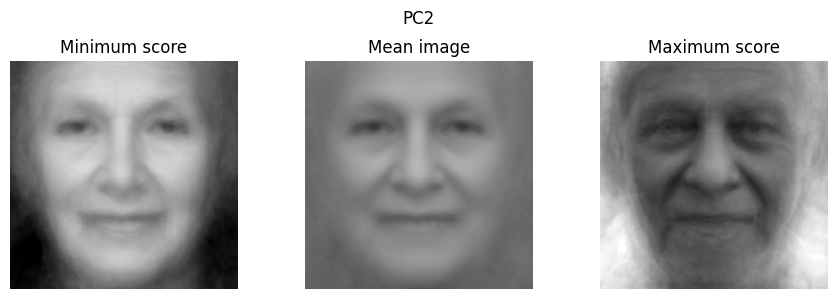

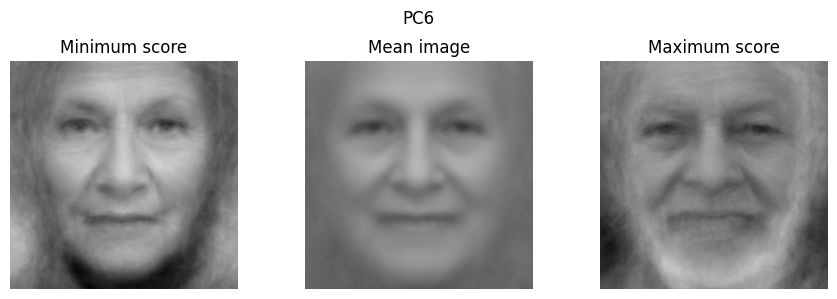

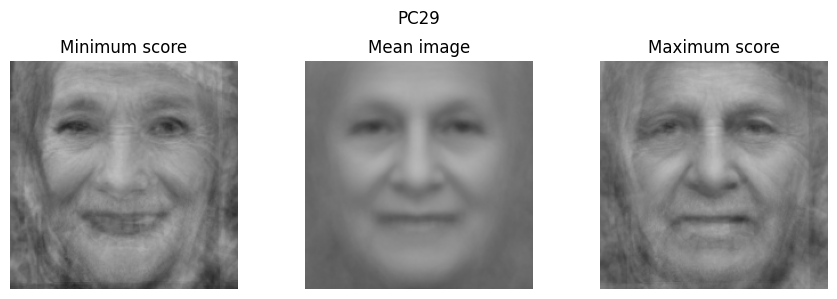

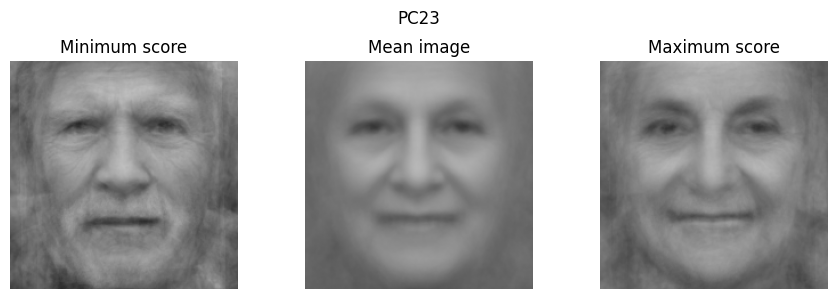

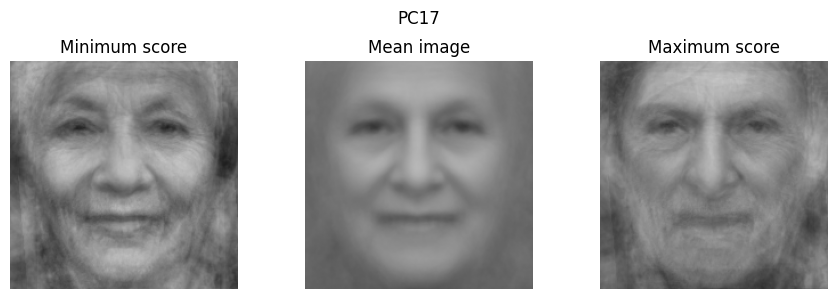

In [37]:
# Look at the components the selection picked, using the same three-image view as in step 3.
# We want to see whether they actually show something related to perceived sex, or just lighting and other things.
for nr in final_pcs[:5]:
    pc = pca.components_[nr]
    scores = Z[:, nr]

    imgs = [mean_img + scores.min() * pc, mean_img, mean_img + scores.max() * pc]
    titles = ["Minimum score", "Mean image", "Maximum score"]

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, img, t in zip(axes, imgs, titles):
        ax.imshow(img.reshape(SIZE), cmap="gray", vmin=0, vmax=255)
        ax.set_title(t)
        ax.axis("off")

    fig.suptitle(f"PC{nr + 1}")
    plt.tight_layout()
    plt.show()

### Step 5 synthetic face generation

In [ ]:
#generate synthetic images based on rating
